# What's Really Inside the S&P 500?
## Phase 1: Data Collection and Cleaning

**Central Question:** What's really inside the S&P 500? Analyzing the composition, concentration, and turnover of the world's most popular index to understand what investors are actually buying.

---

### Overview

This notebook collects and cleans the raw data needed for analysis:

1. **S&P 500 company list** — scraped from Wikipedia
2. **Historical price data** — for the index, sector ETFs, and the largest companies
3. **Data cleaning** — handling missing values, aligning dates, and saving to CSV

All cleaned datasets are saved to a local `data/` folder for use in later phases.

---
## Step 0: Libraries & Setup

Libraries used:

- **pandas** — data manipulation and analysis
- **yfinance** — pulls stock market data from Yahoo Finance
- **matplotlib / seaborn** — data visualization
- **requests** — handles HTTP requests (needed to scrape Wikipedia)
- **datetime** — date calculations
- **os** — file and folder management

Also setting chart defaults and creating the `data/` output folder.

In [ ]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import os
import time
import requests

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

os.makedirs('data', exist_ok=True) 

print("Libraries loaded successfully!")


Libraries loaded successfully!


---
## Step 1: S&P 500 Company List

Wikipedia maintains a current list of all S&P 500 companies here:  
https://en.wikipedia.org/wiki/List_of_S%26P_500_companies

Using `requests` to fetch the page (Wikipedia blocks raw `read_html` calls) and `pd.read_html()` to parse the HTML tables into DataFrames.

Key fields from this table: ticker symbol, company name, GICS sector, sub-industry, headquarters, and date added to the index.

### 1A: Scrape the company list

In [ ]:
#Scraping the S&P 500 company list from Wikipedia

url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'
headers = {'User-Agent': 'Mozilla/5.0'}
response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)
companies = tables[0]

print(f'Number of companies: {len(companies)}')
print(f'Columns avaliable: {list(companies.columns)}')
companies.head(10)

C:\Users\manen\AppData\Local\Temp\ipykernel_20564\1008057923.py:7: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


Number of companies: 503
Columns avaliable: ['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'CIK', 'Founded']


,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989
5,ADBE,Adobe Inc.,Information Technology,Application Software,"San Jose, California",1997-05-05,796343,1982
6,AMD,Advanced Micro Devices,Information Technology,Semiconductors,"Santa Clara, California",2017-03-20,2488,1969
7,AES,AES Corporation,Utilities,Independent Power Producers & Energy Traders,"Arlington, Virginia",1998-10-02,874761,1981
8,AFL,Aflac,Financials,Life & Health Insurance,"Columbus, Georgia",1999-05-28,4977,1955
9,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,"Santa Clara, California",2000-06-05,1090872,1999


### 1B: Sector breakdown

Quick sanity check — counting companies per sector to make sure the data looks reasonable.

In [6]:
#Counting companies per sector
sector_counts = companies['GICS Sector'].value_counts()
print(sector_counts)
print(f'Total: {sector_counts.sum()}')


GICS Sector
Industrials               79
Financials                76
Information Technology    73
Health Care               59
Consumer Discretionary    48
Consumer Staples          35
Utilities                 31
Real Estate               31
Materials                 26
Communication Services    23
Energy                    22
Name: count, dtype: int64
Total: 503


### 1C: Clean the company list

Cleaning steps:
1. Keep only the columns needed for analysis
2. Rename columns for consistency (e.g., 'Symbol' → 'ticker')
3. Fix ticker formatting — Wikipedia uses dots (`BRK.B`), Yahoo Finance expects dashes (`BRK-B`)
4. Convert `date_added` to datetime
5. Save to CSV

In [7]:
#Cleaning the company list
companies_clean = companies[['Symbol', 'Security', 'GICS Sector', 'GICS Sub-Industry', 'Headquarters Location', 'Date added', 'Founded']].copy()
companies_clean.columns = ['ticker', 'company', 'sector', 'sub_industry', 'headquarters', 'date_added', 'founded']

companies_clean.head()


,ticker,company,sector,sub_industry,headquarters,date_added,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1989


In [8]:
#Fixing the ticker symbols
companies_clean['ticker'] = companies_clean['ticker'].str.replace('.', '-', regex=False)

#Converting the dates
companies_clean['date_added'] = pd.to_datetime(companies_clean['date_added'], errors='coerce')

In [9]:
#Saving as a CSV
companies_clean.to_csv('data/sp500_companies.csv', index=False)
print(f'Saved {len(companies_clean)} companies to data/sp500_companies.csv')
companies_clean.head()


Saved 503 companies to data/sp500_companies.csv


,ticker,company,sector,sub_industry,headquarters,date_added,founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1989


---
## Step 2: S&P 500 Index History

Pulling 10 years of daily price data for the S&P 500 index (`^GSPC` on Yahoo Finance). This covers COVID (2020), the 2022 rate hike selloff, and the AI-driven rally (2023–present).

Stock data columns: Open, High, Low, Close, and Volume. Close price is the standard for analysis, it represents the final price at the end of each trading day.

In [10]:
#Setting up the dates (10 yrs)
end_date = datetime.today().strftime('%Y-%m-%d') #date
start_date = (datetime.today() - timedelta(days=365*10)).strftime('%Y-%m-%d') #10 yrs ago
print(f'Pulling data from {start_date} to {end_date}')


Pulling data from 2016-03-27 to 2026-03-25


In [11]:
#Downloading S&P 500 index history (10 years)
sp500_index = yf.download('^GSPC', start=start_date, end=end_date)

print(f'Rows downloaded: {len(sp500_index)}')
print(f'Date range: {sp500_index.index.min()} to {sp500_index.index.max()}')
sp500_index.head()

[*********************100%***********************]  1 of 1 completed

Rows downloaded: 2513
Date range: 2016-03-28 00:00:00 to 2026-03-24 00:00:00


Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
2016-03-28,2037.050049,2042.670044,2031.959961,2037.890015,2809090000
2016-03-29,2055.010010,2055.909912,2028.310059,2035.750000,3822330000
2016-03-30,2063.949951,2072.209961,2058.270020,2058.270020,3590310000
2016-03-31,2059.739990,2067.919922,2057.459961,2063.770020,3715280000
2016-04-01,2072.780029,2075.070068,2043.979980,2056.620117,3749990000


### 2A: Visual check & save

Plotting the close price over time as a quick check, the overall shape should show a clear upward trend with visible dips at known events (COVID crash, 2022 selloff, etc.).

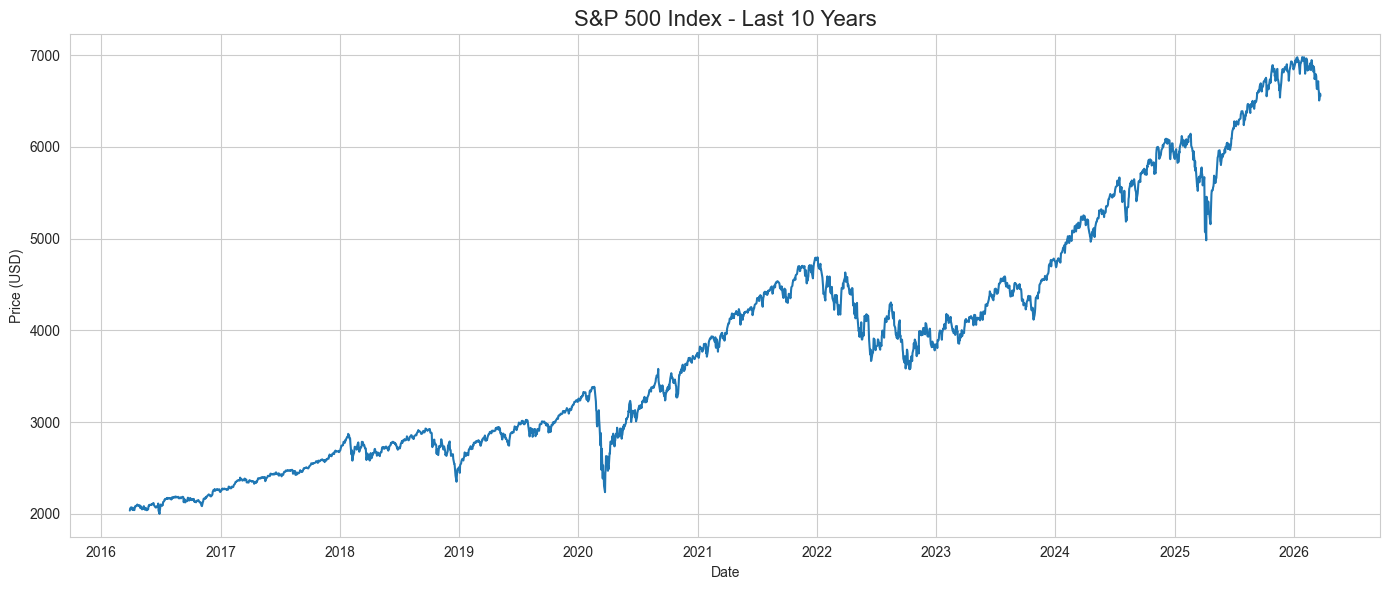

In [30]:
# Ploting the index(specifically the closing price over 10 yrs)
plt.figure(figsize=(14, 6))
plt.plot(sp500_index['Close'])
plt.title('S&P 500 Index - Last 10 Years', fontsize=16)
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.tight_layout()
plt.show()


In [13]:
#Saving the csv
sp500_index.to_csv('data/sp500_index_history.csv')
print('Saved: data/sp500_index_history.csv')

Saved: data/sp500_index_history.csv


---
## Step 3: Sector ETF History

Each of the 11 S&P 500 sectors has a corresponding ETF that tracks just that slice of the index. Comparing sector ETF performance over time shows which sectors have been driving the index.

| Ticker | Sector | Example Companies |
|--------|--------|-------------------|
| XLK | Technology | Apple, Microsoft, Nvidia |
| XLV | Health Care | UnitedHealth, Johnson & Johnson |
| XLF | Financials | Berkshire Hathaway, JPMorgan |
| XLY | Consumer Discretionary | Amazon, Tesla |
| XLC | Communication Services | Meta, Alphabet |
| XLI | Industrials | Caterpillar, Honeywell |
| XLP | Consumer Staples | Procter & Gamble, Coca-Cola |
| XLE | Energy | ExxonMobil, Chevron |
| XLU | Utilities | NextEra Energy, Duke Energy |
| XLRE | Real Estate | American Tower, Prologis |
| XLB | Materials | Linde, Sherwin-Williams |

**Note:** XLC (Communication Services) was created in June 2018, so it has missing values for earlier dates. XLRE (Real Estate) was split from Financials in 2015.

In [31]:
#Defining each sector ETF to its name
sector_etfs = {
    'XLK': 'Technology',
    'XLV': 'Health Care',
    'XLF': 'Financials',
    'XLY': 'Consumer Discretionary',
    'XLC': 'Communication Services',
    'XLI': 'Industrials',
    'XLP': 'Consumer Staples',
    'XLE': 'Energy',
    'XLU': 'Utilities',
    'XLRE': 'Real Estate',
    'XLB': 'Materials'
}

#Getting the ticker symbols as a list and downloading all ETFs
sector_tickers = list(sector_etfs.keys())
print(f'Downloading data for {len(sector_tickers)} sector ETFs...')
sector_data = yf.download(sector_tickers, start=start_date, end=end_date)['Close']

[*********************100%***********************]  11 of 11 completed


In [32]:
#Handling the missing data
sector_data_clean = sector_data.ffill()
print(f'\nRows: {len(sector_data)}')
print(f'\nMissing values per sector:')
print(sector_data_clean.isnull().sum())


Rows: 2513

Missing values per sector:
Ticker
XLB       0
XLC     562
XLE       0
XLF       0
XLI       0
XLK       0
XLP       0
XLRE      0
XLU       0
XLV       0
XLY       0
dtype: int64


In [33]:
#Saving the csv
sector_data_clean.to_csv('data/sector_etf_history.csv')
print('Saved: data/sector_etf_history.csv')

Saved: data/sector_etf_history.csv


---
## Step 4: Top Companies by Market Cap

The S&P 500 is weighted by market capitalization (share price × shares outstanding). A company worth $3 trillion has far more influence on the index than one worth $20 billion. To measure concentration, I need market cap data for every company and price history for the largest ones.

### 4A: Fetch market cap for all companies

Querying `yf.Ticker().info` for each of the ~503 companies individually. Using `try/except` so a single failed request doesn't crash the entire loop. Takes 3–5 minutes.

In [ ]:
#Getting the market cap for all S&P 500 companies
print('Fetching market cap data for all S&P 500 companies')

#Empty list to store results and errors
market_caps = []
errors = []

tickers = companies_clean['ticker'].tolist()

#Try block to avoid crash
for i, ticker in enumerate(tickers):
    # stock = yf.Ticker(ticker)
    # info = stock.info
    # market_cap = info.get('marketCap', None)
    # market_caps.append({'ticker': ticker, 'market_cap': market_cap})
    try:
        stock = yf.Ticker(ticker)
        info = stock.info
        market_cap = info.get('marketCap', None)
        market_caps.append({'ticker': ticker, 'market_cap': market_cap})
    except Exception as e:
        errors.append(ticker)
        market_caps.append({'ticker': ticker, 'market_cap': None})
    
    #Prints every 50 so I know the loop is working
    if (i + 1) % 50 == 0:
        print(f'Processed {i + 1}/{len(tickers)} companies...')

print(f'Done. Errors on {len(errors)} tickers: {errors}')
        

Fetching market cap data for all S&P 500 companies
Processed 50/503 companies...
Processed 100/503 companies...
Processed 150/503 companies...
Processed 200/503 companies...
Processed 250/503 companies...
Processed 300/503 companies...
Processed 350/503 companies...
Processed 400/503 companies...
Processed 450/503 companies...
Processed 500/503 companies...
Done. Errors on 0 tickers: []


### 4B: Identify the top 20

Merging market cap data with the company list, sorting by size, and displaying the 20 largest companies. Saving the full list with market caps for later analysis.

In [43]:
#Merging, sorting, and displaying the top 20
market_cap_df = pd.DataFrame(market_caps)
# market_cap_df.head(10)

sp500_mcap = companies_clean.merge(market_cap_df, on='ticker', how='left')

sp500_mcap = sp500_mcap.sort_values('market_cap', ascending=False).reset_index(drop=True)

#New column in billions for readability (/1 billion)
sp500_mcap['market_cap_billions'] = sp500_mcap['market_cap']/1e9

print('Top 20 S&P 500 companies by market cap:')
top20 = sp500_mcap.head(20)[['ticker', 'company', 'sector', 'market_cap_billions']].copy()
top20['market_cap_billions'] = top20['market_cap_billions'].round(1)
top20.index = range(1,21)
top20

Top 20 S&P 500 companies by market cap:


,ticker,company,sector,market_cap_billions
1,NVDA,Nvidia,Information Technology,4162.0
2,AAPL,Apple Inc.,Information Technology,3717.0
3,GOOGL,Alphabet Inc. (Class A),Communication Services,3398.3
4,GOOG,Alphabet Inc. (Class C),Communication Services,3396.1
5,MSFT,Microsoft,Information Technology,2720.0
6,AMZN,Amazon,Consumer Discretionary,2227.9
7,AVGO,Broadcom,Information Technology,1467.0
8,TSLA,"Tesla, Inc.",Consumer Discretionary,1396.3
9,META,Meta Platforms,Communication Services,1385.0
10,BRK-B,Berkshire Hathaway,Financials,1025.1


In [44]:
#Saving the company list
sp500_mcap.to_csv('data/sp500_companies_market_cap.csv', index=False)
print('Saved: data/sp500_companies_market_cap.csv')

Saved: data/sp500_companies_market_cap.csv


### 4C: Price history for the top 20

Downloading 10 years of daily close prices for the top 20 companies. This data is needed in Phase 3 to calculate how much of the index's total return comes from just these stocks.

In [ ]:
#Downloading top 20 price history
top20_tickers = sp500_mcap.head(20)['ticker'].tolist()
print(f'Downloading the price history for top 20 companies: {top20_tickers}')

top20_prices = yf.download(top20_tickers, start=start_date, end=end_date)['Close']
top20_prices_clean = top20_prices.ffill()
# top20_prices_clean

print(f'Rows: {len(top20_prices_clean)}')
print(f'Missing values: {top20_prices_clean.isnull().sum().sum()}')

[*********************100%***********************]  20 of 20 completed


Rows: 2513
Missing values: 0
Saved: data/top20_price_history.csv


In [ ]:
#Saving
top20_prices_clean.to_csv('data/top20_price_history.csv')
print('Saved: data/top20_price_history.csv')

---
## Step 5: Data Quality Check

Verifying all datasets before moving to analysis: checking row counts, date ranges, missing values, and confirming all files saved correctly.

In [63]:
#Data Quality Summary
#Number of Companies and Sectors
print(f'\n1. Company List')
print(f'Total companies: {len(companies_clean)} companies')
print(f'Total sectors: {companies_clean["sector"].nunique()}')

#Number of Trading Days and Date Range
print(f'\n2. Index History')
print(f'Trading days: {len(sp500_index)}')
print(f'Date range: {sp500_index.index.min().date()} to {sp500_index.index.max().date()}')

#Number of Sectors in the ETF data and missing values
print(f'\n3. Sector ETFs')
print(f'Sectors: {len(sector_data_clean.columns)}')
print(f'Missing values: {sector_data_clean.isnull().sum().sum()}')

#Top 20 Companies check
print(f'\n4. Top 20 Companies')
print(f'Price history rows: {len(top20_prices_clean)}')
print(f'Missing values: {top20_prices_clean.isnull().sum().sum()}')

#All saved files and sizes
print(f'\n5. Files Saved')
for f in os.listdir('data'):
  size = os.path.getsize(f'data/{f}')/1024
  print(f'{f} ({size:.1f} KB)')



1. Company List
Total companies: 503 companies
Total sectors: 11

2. Index History
Trading days: 2513
Date range: 2016-03-28 to 2026-03-24

3. Sector ETFs
Sectors: 11
Missing values: 562

4. Top 20 Companies
Price history rows: 2513
Missing values: 0

5. Files Saved
sector_etf_history.csv (513.0 KB)
sp500_companies.csv (49.4 KB)
sp500_companies_market_cap.csv (61.7 KB)
sp500_index_history.csv (217.0 KB)
top20_price_history.csv (923.0 KB)


---
## Summary

Five datasets collected and saved:

| File | Contents |
|------|----------|
| `sp500_companies.csv` | All current S&P 500 companies — ticker, sector, HQ, date added |
| `sp500_companies_market_cap.csv` | Same as above with current market cap |
| `sp500_index_history.csv` | 10 years of daily S&P 500 index prices |
| `sector_etf_history.csv` | 10 years of daily close prices for all 11 sector ETFs |
| `top20_price_history.csv` | 10 years of daily close prices for the 20 largest companies |

**Next: Phase 2 — Sector Analysis**